In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_final=pd.read_csv('data/output/final_Data.csv')
df_final_data_copy = df_final.copy()
df_final_data_copy.drop(columns=['reuna','issuer','issue','check_digit','issuer+issue','gvkey'], inplace=True)
df_final_data_copy['datadate']= pd.to_datetime(df_final_data_copy['datadate'])
df_final_data_copy['ipodate']= pd.to_datetime(df_final_data_copy['ipodate'])
df_final_data_copy['ENDDAT']= pd.to_datetime(df_final_data_copy['ENDDAT'])
df_final_data_copy = df_final_data_copy.dropna(subset=['fyear'])
df_final_data_copy['fyear'] = df_final_data_copy['fyear'].astype(int)
columns_of_fin_Values = ['at','lt','ebit','mkvalt','sale','re','wcap']
columns_of_ratios = ['liquidity','re/at','profitability','mkvalt/lt','AssetTurnoverRatio']
df_final_data_copy.shape

/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/1879261770.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final=pd.read_csv('data/output/final_Data.csv')


(357692, 26)

In [ ]:
df_final_data_copy.info()

In [ ]:
print(df_final_data_copy['ipodate'].isna().sum())
print("fina_values nulls:", df_final_data_copy[columns_of_fin_Values].isna().sum())

In [3]:
df_left_censored_data = df_final_data_copy[df_final_data_copy['ipodate'].isna()]
df_final_data_copy = df_final_data_copy[~df_final_data_copy['ipodate'].isna()]
df_final_data_copy.shape

(153207, 26)

In [ ]:
df_final_data_copy['cusip'].nunique()

### creating a data set with Forward Fill imputing for the fin values

In [ ]:
df_final_data_copy.isna().sum()

In [ ]:
df_final_data_copy = df_final_data_copy.sort_values(by=['cusip','fyear'])
df_final_data_copy_ffill = df_final_data_copy.groupby('cusip').ffill()
df_final_data_copy_ffill.isna().sum()

### Creating a Data set with iterative imputer

In [4]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=42)
copy = df_final_data_copy.copy()
copy[columns_of_fin_Values] = copy[columns_of_fin_Values].replace([np.inf, -np.inf], np.nan)
copy[columns_of_fin_Values] = imputer.fit_transform(copy[columns_of_fin_Values])
copy.isna().sum()

/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


datadate                  0
fyear                     0
cusip                     0
ipodate                   0
conm                      0
at                        0
sale                      0
ebit                      0
re                        0
wcap                      0
mkvalt                    0
lt                        0
gsector                4015
indfmt                    0
liquidity             47263
re/at                 16579
profitability         28496
mkvalt/lt             67590
AssetTurnoverRatio    27486
PERMNO                    0
DLSTCD                    0
HCOMNAM                   0
CUSIP                     0
HEXCD                     0
BEGDAT                    0
ENDDAT                    0
dtype: int64

In [5]:
copy["liquidity"] = copy['wcap']/copy['at']
copy["re/at"] = copy['re']/copy['at']
# df_covariates["reuna/at"] = df_step1['reuna']/df_step1['at']
copy["profitability"] = copy['ebit']/copy['at']
copy["mkvalt/lt"] = copy['mkvalt']/copy['lt']
copy["AssetTurnoverRatio"] = copy['sale']/copy['at']
copy.isna().sum()

datadate                 0
fyear                    0
cusip                    0
ipodate                  0
conm                     0
at                       0
sale                     0
ebit                     0
re                       0
wcap                     0
mkvalt                   0
lt                       0
gsector               4015
indfmt                   0
liquidity               11
re/at                    7
profitability            8
mkvalt/lt                0
AssetTurnoverRatio      36
PERMNO                   0
DLSTCD                   0
HCOMNAM                  0
CUSIP                    0
HEXCD                    0
BEGDAT                   0
ENDDAT                   0
dtype: int64

In [6]:
copy[columns_of_ratios]=copy[columns_of_ratios].replace([np.inf, -np.inf], np.nan)
copy[columns_of_ratios].isna().sum()

liquidity             48
re/at                 48
profitability         48
mkvalt/lt             60
AssetTurnoverRatio    48
dtype: int64

In [7]:
copy.dropna(subset=columns_of_ratios, inplace=True)
copy.isna().sum()

datadate                 0
fyear                    0
cusip                    0
ipodate                  0
conm                     0
at                       0
sale                     0
ebit                     0
re                       0
wcap                     0
mkvalt                   0
lt                       0
gsector               4012
indfmt                   0
liquidity                0
re/at                    0
profitability            0
mkvalt/lt                0
AssetTurnoverRatio       0
PERMNO                   0
DLSTCD                   0
HCOMNAM                  0
CUSIP                    0
HEXCD                    0
BEGDAT                   0
ENDDAT                   0
dtype: int64

# EDA

In [ ]:
import seaborn as sns

# Plot pairwise scatterplots
sns.pairplot(df_final_data_copy[columns_of_ratios])
plt.show()

In [ ]:
import seaborn as sns

# Plot pairwise scatterplots
sns.pairplot(copy[columns_of_ratios])
plt.show()

## Preprocessing the data

In [10]:
def preprocessing_datasets(df):
    #Step 1
    print("No of records with fyear less than ipodate year:")
    print(df[df['fyear']<df['ipodate'].dt.year].shape)
    print("No of records with fyear greater than or equal to ipodate year:")
    print(df[df['fyear']>=df['ipodate'].dt.year].shape)
    df = df[df['fyear']>=df['ipodate'].dt.year]
    print(df.shape)
    # Step 2
    print("no of records with fyear less than enddate year i.e. Bankruptcy:")
    print(df[~((df['fyear']>df['ENDDAT'].dt.year)&(df['DLSTCD'].astype(str).str.startswith('4')))].shape)
    print("no of records with fyear greater than enddate year i.e. Bankruptcy:")
    print(df[((df['fyear']>df['ENDDAT'].dt.year)&(df['DLSTCD'].astype(str).str.startswith('4')))].shape)
    df = df[~((df['fyear']>df['ENDDAT'].dt.year)&(df['DLSTCD'].astype(str).str.startswith('4')))]
    print(df.shape)
    #step 3
    print("No of records with ipodate between 2010-2023:")
    print(df[df['ipodate'].between('2010-01-01','2023-12-31')].shape)
    print("No of records with ipodate not between 2010-2023:")
    print(df[~df['ipodate'].between('2010-01-01','2023-12-31')].shape)
    df=df[df['ipodate'].between('2010-01-01','2023-12-31')]
    df=df[df['ipodate'].between('2010-01-01','2023-12-31')]
    print(df.shape)
    # step 4
    print("No of records with ENDDAT >= ipodate:")
    print(df[df['ENDDAT']>=df['ipodate']].shape)
    print("No of records with ENDDAT < ipodate:")
    print(df[df['ENDDAT']<df['ipodate']].shape)
    df =df[df['ENDDAT']>=df['ipodate']]
    print(df.shape)
    return df

In [11]:
df_final_data_copy = preprocessing_datasets(df_final_data_copy)
print("-------------------------------------------------------------")
# df_final_data_copy_ffill = preprocessing_datasets(df_final_data_copy_ffill)
print("-------------------------------------------------------------")
copy = preprocessing_datasets(copy)

No of records with fyear less than ipodate year:
(25671, 26)
No of records with fyear greater than or equal to ipodate year:
(127536, 26)
(127536, 26)
no of records with fyear less than enddate year i.e. Bankruptcy:
(127533, 26)
no of records with fyear greater than enddate year i.e. Bankruptcy:
(3, 26)
(127533, 26)
No of records with ipodate between 2010-2023:
(17314, 26)
No of records with ipodate not between 2010-2023:
(110219, 26)
(17314, 26)
No of records with ENDDAT >= ipodate:
(17314, 26)
No of records with ENDDAT < ipodate:
(0, 26)
(17314, 26)
-------------------------------------------------------------
-------------------------------------------------------------
No of records with fyear less than ipodate year:
(25629, 26)
No of records with fyear greater than or equal to ipodate year:
(127481, 26)
(127481, 26)
no of records with fyear less than enddate year i.e. Bankruptcy:
(127478, 26)
no of records with fyear greater than enddate year i.e. Bankruptcy:
(3, 26)
(127478, 26)


IF we consider only the fyear >= 2023 and DLSTCD not starting with 4, thne only those rows of the companies where fyear = 2023 and 2024 will be marked as censored.
By taking DLSTCD not starting with 4, then we put censored = 0 for all rows of companies which are censored.
Here The idea is:
Companies with DLSTCD starting with 4 is considered and bankrupted and their end date is date of bankruptcy
And companies with DLSTCD not starting with 4 are not bankrupted and max(fyear) denotes their censored time
Here Censored and event are mutually exclusive

Suvival times in days is calculated as :
Survival time = enddate - ipodate
censored time = max(fyear) of the cusip - ipodate( taking 31 st of dec of fyear)

In [12]:
def survivaltimes(df):
    df['censored'] = np.where(~(df['DLSTCD'].astype(str).str.startswith('4')) , 0, 1)
    df['event'] = np.where((df['DLSTCD'].astype(str).str.startswith('4')) , 1, 0)
    max_fyear = df.groupby('cusip')['fyear'].max().reset_index()
    max_fyear.columns = ['cusip', 'max_fyear']
    # Merge the maximum 'fyear' with the original DataFrame
    df = df.merge(max_fyear, on='cusip', how='left')
    df['survival_time_in_Days'] =  np.where(df['censored']==1, df['ENDDAT'] - df['ipodate'],pd.to_datetime(df['max_fyear'].astype(str) + '-12-31') - df['ipodate'])
    df['survival_time_in_years'] = np.where(df['censored']==1, df['ENDDAT'].dt.year - df['ipodate'].dt.year,df['max_fyear'] - df['ipodate'].dt.year)

    df['bankruptcy']=np.where((((df['ENDDAT'].dt.year==df['fyear'])|(df['ENDDAT'].dt.year==df['fyear']+1)) & (df['DLSTCD'].astype(str).str.startswith('4'))) , 1, 0)
    return df

In [13]:
df_final_data_copy = survivaltimes(df_final_data_copy)
copy = survivaltimes(copy)

In [14]:
def split_Data(df):
    df_financial_Data = df[df['indfmt']=='FS']
    df_industrial_data  = df[df['indfmt']=='INDL']
    print("financial data",df_financial_Data.shape)
    print("Industrial data",df_industrial_data.shape)
    print(df_industrial_data['gsector'].isna().sum())
    # Converting the gsector to integer
    df_industrial_data.loc[:,'gsector'] = df_industrial_data.loc[:,'gsector'].replace([np.inf, -np.inf], np.nan)
    df_industrial_data.loc[:,'gsector'] = df_industrial_data.loc[:,'gsector'].fillna(0)
    df_industrial_data.loc[:,'gsector'] = df_industrial_data.loc[:,'gsector'].astype(int)
    df_industrial_data = df_industrial_data.sort_values(by=['cusip','fyear'],ascending= [True,True] )
    return df_financial_Data,df_industrial_data

In [15]:
copy_financial_Data, copy_industrial_data = split_Data(copy)
df_financial_Data, df_industrial_data = split_Data(df_final_data_copy)
# df_financial_Data_ffill, df_industrial_data_ffill = split_Data(df_final_data_copy_ffill)

financial data (1470, 32)
Industrial data (15825, 32)
376
financial data (1470, 32)
Industrial data (15844, 32)
376


 Writing it out to share the data

In [16]:
df_industrial_data.to_csv('data/output/df_base_data.csv',index=False)

In [ ]:
print(df_industrial_data['fyear'].value_counts().sort_index())
print(copy_industrial_data['fyear'].value_counts().sort_index())
print(" No  of unique companies in industrial data:")
print(df_industrial_data['cusip'].nunique())
print(copy_industrial_data['cusip'].nunique())

print("No of rows with all 5 ratios as NAN,4 ratios as NAN,3 ratios as NAN,2 ratios as NAN,1 ratio as NAN,0 ratio as NAN")
nans = df_industrial_data[columns_of_ratios].isna().sum(axis=1)
nans.value_counts().sort_index()
print(df_industrial_data['DLSTCD'].value_counts().sort_index())
print(copy_industrial_data['DLSTCD'].value_counts().sort_index())
print("Value counts of survival time in years i.e. No of records with survival time in years:")
print(df_industrial_data['survival_time_in_years'].value_counts().sort_index(ascending=False).cumsum())
print("No of unique companies with survival time in years:")
print(df_industrial_data.groupby(['survival_time_in_years'])['cusip'].nunique().sort_index(ascending=False).cumsum())
print(df_industrial_data[df_industrial_data['censored']==1]['cusip'].nunique())
# print(df_industrial_data[df_industrial_data['bankruptcy']==1].sort_values(by=['cusip','fyear'],ascending=[True,True]))

## Kaplan Meir

In [17]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
def kaplan_Meier_model(df):
    # Survival time 
    # Group by company_id and aggregate
    df_aggregated_data = df.groupby('cusip').agg({
        'survival_time_in_years': 'max',  # Use the maximum survival time (time to event or censoring)
        'survival_time_in_Days': 'max', 
        'bankruptcy': 'max'           # Use the maximum event value (1 if bankrupt, 0 otherwise)
    }).reset_index()

    # Fit the Kaplan-Meier model
    kmf = KaplanMeierFitter()
    kmf.fit(df_aggregated_data['survival_time_in_years'], event_observed=df_aggregated_data['bankruptcy'])
    # Plot the survival curve
    kmf.plot_survival_function()
    plt.title('Kaplan-Meier Survival Curve with years')
    plt.xlabel('Time (Years)')
    plt.ylabel('Survival Probability')
    plt.show()

    # Fit the Kaplan-Meier model
    kmf = KaplanMeierFitter()
    kmf.fit(df_aggregated_data['survival_time_in_Days'], event_observed=df_aggregated_data['bankruptcy'])
    # Plot the survival curve
    kmf.plot_survival_function()
    plt.title('Kaplan-Meier Survival Curve with days')
    plt.xlabel('Time (days)')
    plt.ylabel('Survival Probability')
    plt.show()


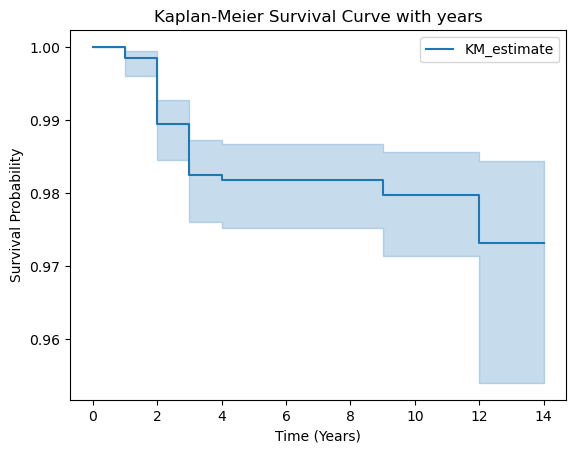

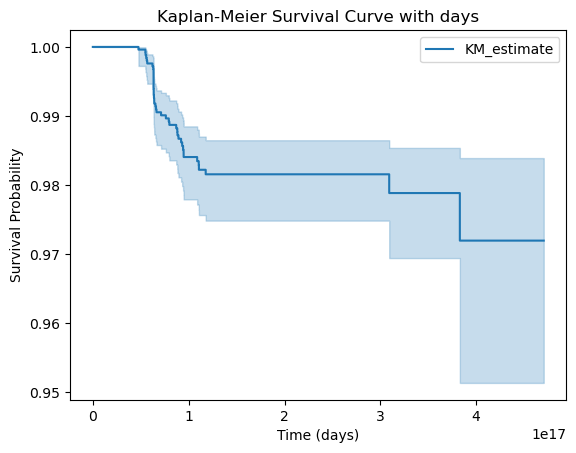

In [18]:
kaplan_Meier_model(df_industrial_data)

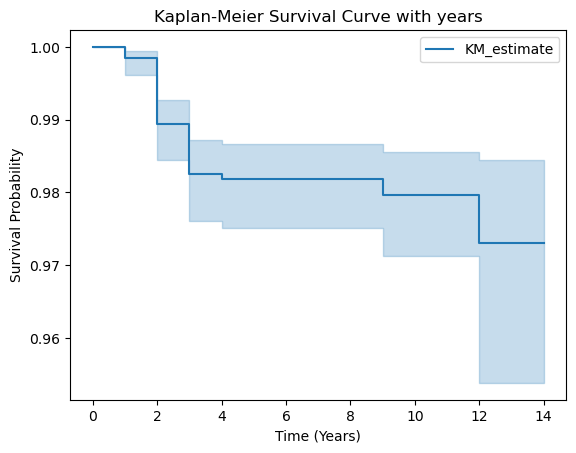

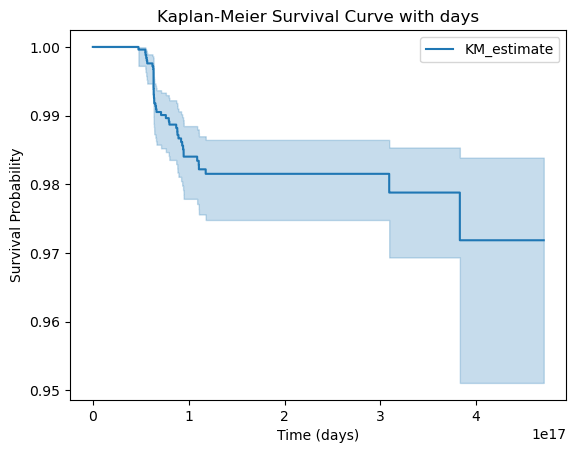

In [19]:
kaplan_Meier_model(copy_industrial_data)

# Modelling

## Cox Proportional Hazards Model with Time-Dependent Covariates

In [76]:
import pandas as pd
from lifelines import CoxTimeVaryingFitter
# Import the Cox Proportional Hazard model class
from lifelines import CoxPHFitter

def cox_proportional_hazard_model(df,columns_list: list):
    # # Create a new model
    # cph = CoxPHFitter()
    # # Fit the model to the data
    # cph.fit(df, duration_col='survival_time_in_years', event_col='bankruptcy')
    # # Display the model summary
    # cph.print_summary()

    # Calculate start_time and stop_time
    df['start_time'] = (df['fyear'] - df['ipodate'].dt.year).clip(lower=0)
    df['stop_time'] = df['start_time'] + 1  # Each row represents one year
    # Display the prepared data
    cols = ['cusip', 'start_time', 'stop_time', 'bankruptcy']
    cols.extend(columns_list)
    df = df[cols]
    # Fit the Cox model
    ctv = CoxTimeVaryingFitter()
    ctv.fit(df, id_col='cusip', event_col='bankruptcy', start_col='start_time', stop_col='stop_time',show_progress=True)
    # Print summary
    ctv.print_summary()
    # ctv.check_assumptions(df, p_value_threshold=0.05) -> this is for standard cox ph model


In [77]:
cox_proportional_hazard_model(copy_industrial_data,columns_of_ratios)


Iteration 1: norm_delta = 1.52e+00, step_size = 0.9500, log_lik = -333.55384, newton_decrement = 4.37e+00, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.71e+00, step_size = 0.9500, log_lik = -327.66828, newton_decrement = 3.90e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 1.12e+01, step_size = 0.9500, log_lik = -323.27610, newton_decrement = 5.89e+00, seconds_since_start = 0.0
Iteration 4: norm_delta = 5.83e+00, step_size = 0.2327, log_lik = -314.99855, newton_decrement = 7.47e+00, seconds_since_start = 0.0
Iteration 5: norm_delta = 1.99e+00, step_size = 0.0741, log_lik = -311.88619, newton_decrement = 6.36e+00, seconds_since_start = 0.0
Iteration 6: norm_delta = 3.38e+00, step_size = 0.1253, log_lik = -310.97660, newton_decrement = 5.93e+00, seconds_since_start = 0.0
Iteration 7: norm_delta = 4.30e+00, step_size = 0.1596, log_lik = -309.58068, newton_decrement = 5.18e+00, seconds_since_start = 0.0
Iteration 8: norm_delta = 5.36e+00, step_size = 0.2033, log_lik = -30

<lifelines.CoxTimeVaryingFitter: fitted with 15825 periods, 2891 subjects, 43 events>
         event col = 'bankruptcy'
number of subjects = 2891
 number of periods = 15825
  number of events = 43
partial log-likelihood = -302.16
  time fit was run = 2025-03-16 23:36:05 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
liquidity          -1.44      0.24      0.30           -2.04           -0.84                0.13                0.43
re/at               0.05      1.05      0.06           -0.08            0.17                0.92                1.19
profitability       3.67     39.19      0.98            1.74            5.59                5.73              268.25
mkvalt/lt           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
AssetTurnoverRatio -3.02      0.05      0.71           -4.41           -1.63                0.01                0.20

                    cmp to     z      p  -log2(p)
covariate                                        
liquidity             0.00 -4.73 <0.005     18.79
re/at                 0.00  0.73   0.47      1.10
profitability         0.00  3.74 <0.005     12.40
mkvalt/lt             0.00  1.11   0.27      1.90
AssetTurnoverRatio    0.00 -4.26 <0.005     15.56
---
Partial AIC = 614.33
log-likelihood ratio test = 62.78 on 5 df
-log2(p) of ll-ratio test = 38.17

In [78]:
cox_proportional_hazard_model(df_industrial_data,columns_list=columns_of_ratios)

/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column AssetTurnoverRatio have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['bankruptcy'].astype(bool)
>>> print(df.loc[events, 'AssetTurnoverRatio'].var())
>>> print(df.loc[~events, 'AssetTurnoverRatio'].var())

A very low variance means that the column AssetTurnoverRatio completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


LinAlgError: Matrix is singular.

## Random Survival Forest

In [79]:
# RSF
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest

def random_survival_forest(df,columns):
    # Prepare the target variable for RSF
    y = Surv.from_dataframe('bankruptcy', 'stop_time', df)
    # Prepare the feature matrix
    X = df[columns]
    # Initialize and fit the RSF model
    rsf = RandomSurvivalForest()
    rsf.fit(X, y)
    # Check feature importance
    # print(rsf.feature_importances_)
    # Predict survival probabilities
    survival_probabilities = rsf.predict_survival_function(X)
    # Predict risk scores
    risk_scores = rsf.predict(X)
    return survival_probabilities,risk_scores

In [80]:
random_survival_forest(copy_industrial_data,columns_of_ratios)

(array([StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        ...,
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 

In [81]:
random_survival_forest(df_industrial_data,columns_of_ratios)

(array([StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        ...,
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), a=1.0, b=0.0),
        StepFunction(x=array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
               14., 15.]), y=array([1., 1., 1., 1., 1., 1., 

##  Checking Multicollinearity in the variables

In [49]:

import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df):
    # Example dataset
    # df = df[columns_of_ratios]
    # Compute correlation matrix
    corr_matrix = df.corr()
    # Plot the correlation matrix
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Matrix of Covariates')
    plt.show()

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def compute_vif(df):
    # df = df[columns_of_ratios]
    # Add a constant column for the intercept
    df['const'] = 1
    # Compute VIF for each covariate
    vif_data = pd.DataFrame()
    vif_data['Covariate'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    # Display VIF results
    print(vif_data)

In [51]:
import numpy as np
def compute_rank(df):
    # Create a matrix of covariates
    X = df.values
    # Compute the rank of the matrix
    rank = np.linalg.matrix_rank(X)
    print(f"Rank of the matrix: {rank}")

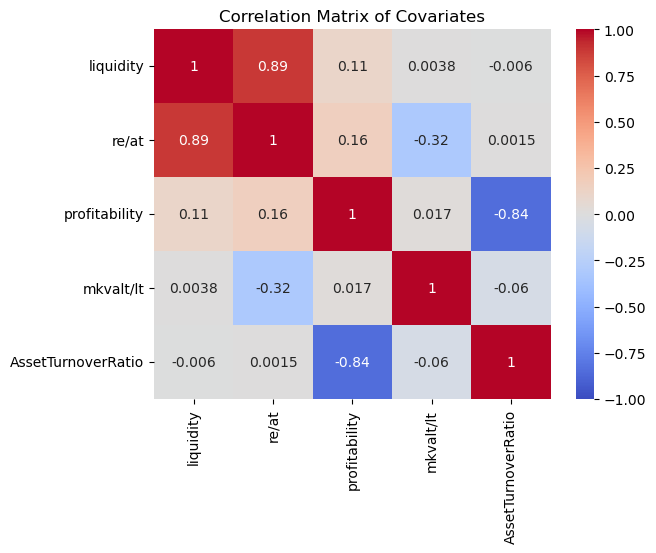

            Covariate        VIF
0           liquidity   8.922068
1               re/at  10.527557
2       profitability   4.184115
3           mkvalt/lt   2.039594
4  AssetTurnoverRatio   3.948534
5               const   1.173224
Rank of the matrix: 5


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [52]:
plot_correlation_matrix(copy_industrial_data[columns_of_ratios])
compute_vif(copy_industrial_data[columns_of_ratios])
compute_rank(copy_industrial_data[columns_of_ratios])

# Imputing the data using soft impute

In [43]:
# imputing  the data
import numpy as np
from py_soft_impute.soft_impute import SoftImpute
def soft_impute(df):
    df_to_impute = df[columns_of_ratios]
    df_to_impute= df_to_impute.replace([np.inf, -np.inf], np.nan)
    df_to_impute = df_to_impute.fillna(0)
    clf = SoftImpute(J=2, lambda_=0.0)
    fit = clf.fit(df_to_impute.values)
    imputed_array = clf.predict(df_to_impute.values)
    df_new=pd.DataFrame(imputed_array, columns=columns_of_ratios)
    df.iloc[:,14:19] = df_new
    return df

In [44]:
df_industrial_data_imputed = soft_impute(df_industrial_data)

In [45]:
df_industrial_data_imputed[columns_of_ratios].isna().sum()

liquidity             0
re/at                 0
profitability         0
mkvalt/lt             0
AssetTurnoverRatio    0
dtype: int64

In [84]:
cox_proportional_hazard_model(df_industrial_data_imputed,columns_of_ratios)

/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column AssetTurnoverRatio have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['bankruptcy'].astype(bool)
>>> print(df.loc[events, 'AssetTurnoverRatio'].var())
>>> print(df.loc[~events, 'AssetTurnoverRatio'].var())

A very low variance means that the column AssetTurnoverRatio completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


LinAlgError: Matrix is singular.

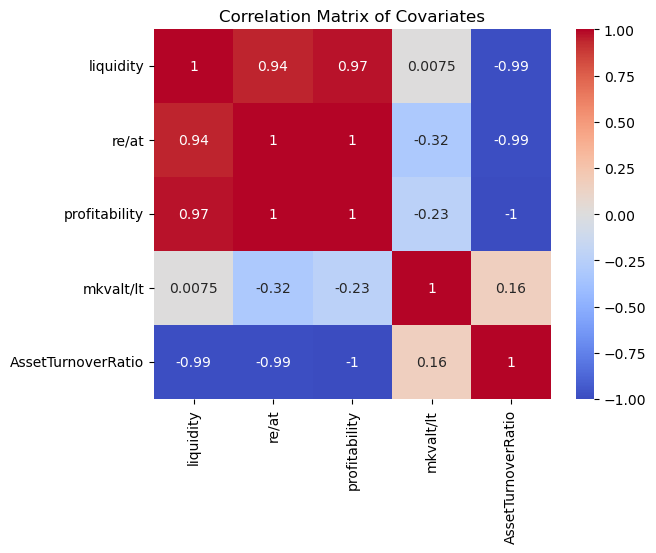

            Covariate       VIF
0           liquidity       inf
1               re/at       inf
2       profitability       inf
3           mkvalt/lt       inf
4  AssetTurnoverRatio       inf
5               const  1.003828
Rank of the matrix: 2


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [83]:
plot_correlation_matrix(df_industrial_data_imputed[columns_of_ratios])
compute_vif(df_industrial_data_imputed[columns_of_ratios])
compute_rank(df_industrial_data_imputed[columns_of_ratios])

In [54]:
# Dropping the ratios with high VIF
df_droped_ratios=df_industrial_data_imputed.drop(columns=['profitability','AssetTurnoverRatio','liquidity'])

In [85]:
cox_proportional_hazard_model(df_droped_ratios,['re/at','mkvalt/lt'])

Iteration 1: norm_delta = 6.86e-01, step_size = 0.9500, log_lik = -333.59207, newton_decrement = 3.34e-01, seconds_since_start = 0.0
Iteration 2: norm_delta = 8.60e-01, step_size = 0.9500, log_lik = -333.37772, newton_decrement = 3.12e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 9.60e-01, step_size = 0.9500, log_lik = -332.97750, newton_decrement = 1.40e-01, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.84e-01, step_size = 0.9310, log_lik = -332.81990, newton_decrement = 1.52e-02, seconds_since_start = 0.0
Iteration 5: norm_delta = 3.21e-02, step_size = 0.9124, log_lik = -332.80345, newton_decrement = 1.12e-03, seconds_since_start = 0.0
Iteration 6: norm_delta = 3.53e-03, step_size = 1.0000, log_lik = -332.80229, newton_decrement = 4.23e-05, seconds_since_start = 0.0
Iteration 7: norm_delta = 3.54e-05, step_size = 1.0000, log_lik = -332.80224, newton_decrement = 2.94e-08, seconds_since_start = 0.0
Iteration 8: norm_delta = 2.53e-08, step_size = 1.0000, log_lik = -33

<lifelines.CoxTimeVaryingFitter: fitted with 15844 periods, 2892 subjects, 43 events>
         event col = 'bankruptcy'
number of subjects = 2892
 number of periods = 15844
  number of events = 43
partial log-likelihood = -332.80
  time fit was run = 2025-03-16 23:42:43 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
re/at      0.10      1.11      0.10           -0.10            0.30                0.91                1.34
mkvalt/lt  0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to    z    p  -log2(p)
covariate                            
re/at        0.00 1.00 0.32      1.66
mkvalt/lt    0.00 1.04 0.30      1.74
---
Partial AIC = 669.60
log-likelihood ratio test = 1.58 on 2 df
-log2(p) of ll-ratio test = 1.14

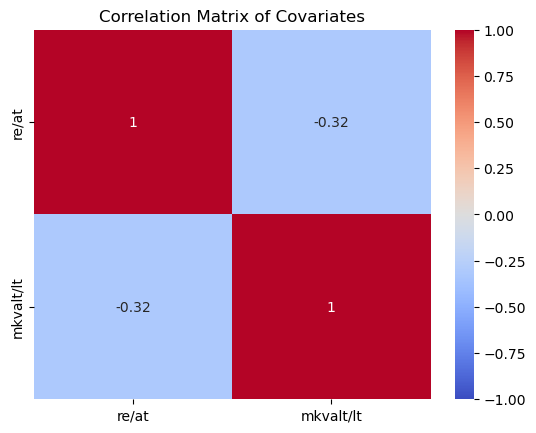

   Covariate       VIF
0      re/at  1.114283
1  mkvalt/lt  1.114283
2      const  1.003828
Rank of the matrix: 2


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [86]:
plot_correlation_matrix(df_droped_ratios[['re/at','mkvalt/lt']])
compute_vif(df_droped_ratios[['re/at','mkvalt/lt']])
compute_rank(df_droped_ratios[['re/at','mkvalt/lt']])

# Filtering on a Specific Sector


In [ ]:
print(df_industrial_data['gsector'].value_counts())
print(copy_industrial_data['gsector'].value_counts())

In [151]:
df_industrial_data_35 = df_industrial_data_imputed[df_industrial_data_imputed['gsector']==35]
copy_industrial_data_35 = copy_industrial_data[copy_industrial_data['gsector']==35]

In [152]:
df_industrial_data_35_6 = df_industrial_data_35[df_industrial_data_35['survival_time_in_years']<=6]
copy_industrial_data_35_6 = copy_industrial_data_35[copy_industrial_data_35['survival_time_in_years']<=6]

In [ ]:
print("Number of NaN values in each row for the columns of ratios:")
print((df_industrial_data_35[columns_of_ratios].isna().sum(axis=1)).value_counts().sort_index())
print("fyear value counts:")
print(df_industrial_data_35['fyear'].value_counts().sort_index())
print("cusip unique values:")
print(df_industrial_data_35['cusip'].nunique())
print("Survival time in years value counts:")
print(df_industrial_data_35['survival_time_in_years'].value_counts().sort_index(ascending=False).cumsum())
print("survival times in years value counts: and cusio unique values")
print(df_industrial_data_35.groupby(['survival_time_in_years'])['cusip'].nunique().sort_index(ascending=False).cumsum())
# ------------------------------------------------------------------------------------------------
print("Number of NaN values in each row for the columns of ratios:")
print((copy_industrial_data_35[columns_of_ratios].isna().sum(axis=1)).value_counts().sort_index())
print("fyear value counts:")
print(copy_industrial_data_35['fyear'].value_counts().sort_index())
print("cusip unique values:")
print(copy_industrial_data_35['cusip'].nunique())
print("Survival time in years value counts:")
print(copy_industrial_data_35['survival_time_in_years'].value_counts().sort_index(ascending=False).cumsum())
print("survival times in years value counts: and cusio unique values")
print(copy_industrial_data_35.groupby(['survival_time_in_years'])['cusip'].nunique().sort_index(ascending=False).cumsum())

In [ ]:
print("Printing years of survival time and no of unique companies survived ")
dict_copy_industrial_data_35_6 = {}
count=0
for x in (copy_industrial_data_35_6.groupby('cusip')['fyear'].unique()):
    #sorting the values in the list x
    x.sort()
    set_x = tuple(x)  # Convert set to tuple
    if set_x not in dict_copy_industrial_data_35_6:
        dict_copy_industrial_data_35_6[set_x] = 1
    else:
        dict_copy_industrial_data_35_6[set_x] += 1     
dict_copy_industrial_data_35_6

### cox model of df_industrial_data_35_6

In [153]:
cox_proportional_hazard_model(df_industrial_data_35_6,columns_of_ratios)

/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = (df['fyear'] - df['ipodate'].dt.year).clip(lower=0)
/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stop_time'] = df['start_time'] + 1  # Each row represents one year
/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarn

LinAlgError: Matrix is singular.

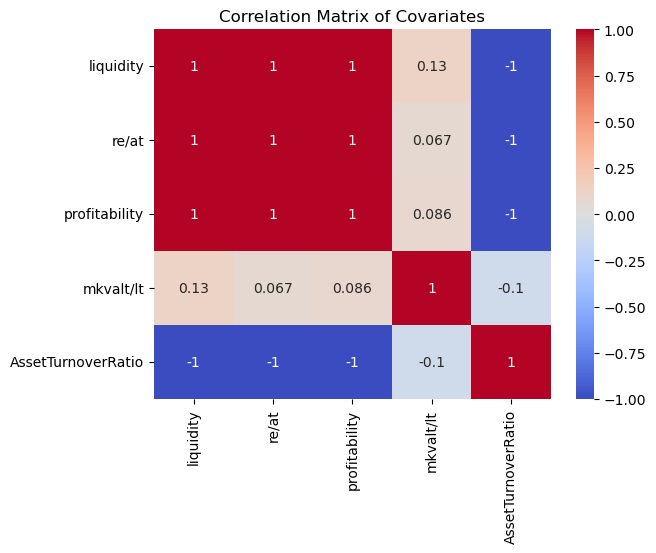

            Covariate       VIF
0           liquidity       inf
1               re/at       inf
2       profitability       inf
3           mkvalt/lt       inf
4  AssetTurnoverRatio       inf
5               const  1.308012
Rank of the matrix: 2


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [154]:
plot_correlation_matrix(df_industrial_data_35_6[columns_of_ratios])
compute_vif(df_industrial_data_35_6[columns_of_ratios])
compute_rank(df_industrial_data_35_6[columns_of_ratios])

In [155]:
df_industrial_data_35_6_droped_ratios = df_industrial_data_35_6.drop(columns=['profitability','liquidity','re/at'])

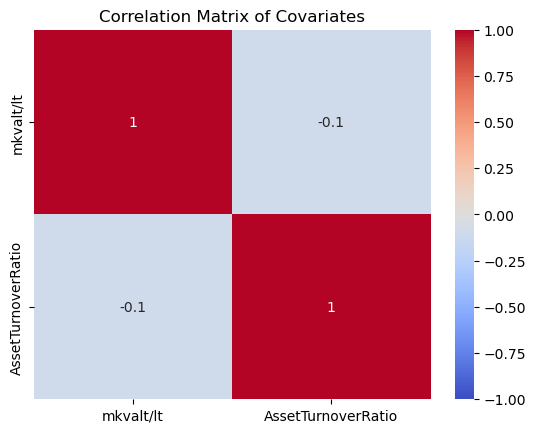

            Covariate       VIF
0           mkvalt/lt  1.010218
1  AssetTurnoverRatio  1.010218
2               const  1.308012
Rank of the matrix: 2


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [156]:
plot_correlation_matrix(df_industrial_data_35_6_droped_ratios[['mkvalt/lt','AssetTurnoverRatio']])
compute_vif(df_industrial_data_35_6_droped_ratios[['mkvalt/lt','AssetTurnoverRatio']])
compute_rank(df_industrial_data_35_6_droped_ratios[['mkvalt/lt','AssetTurnoverRatio']])

In [157]:
cox_proportional_hazard_model(df_industrial_data_35_6_droped_ratios,['mkvalt/lt','AssetTurnoverRatio'])

Iteration 1: norm_delta = 3.41e-01, step_size = 0.9500, log_lik = -6.30810, newton_decrement = 4.99e-02, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.39e+00, step_size = 0.9500, log_lik = -6.23542, newton_decrement = 1.31e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.09e+00, step_size = 0.9500, log_lik = -6.05511, newton_decrement = 1.60e-01, seconds_since_start = 0.0
Iteration 4: norm_delta = 5.60e+00, step_size = 0.9310, log_lik = -5.84096, newton_decrement = 1.51e-01, seconds_since_start = 0.0
Iteration 5: norm_delta = 1.92e+00, step_size = 0.2281, log_lik = -5.64727, newton_decrement = 1.00e-01, seconds_since_start = 0.0
Iteration 6: norm_delta = 2.51e+00, step_size = 0.2906, log_lik = -5.60643, newton_decrement = 8.19e-02, seconds_since_start = 0.0
Iteration 7: norm_delta = 3.15e+00, step_size = 0.3702, log_lik = -5.56514, newton_decrement = 6.04e-02, seconds_since_start = 0.0
Iteration 8: norm_delta = 3.67e+00, step_size = 0.4717, log_lik = -5.52794, newton_

/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['AssetTurnoverRatio'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxTimeVaryingFitter: fitted with 2615 periods, 684 subjects, 1 events>
         event col = 'bankruptcy'
number of subjects = 684
 number of periods = 2615
  number of events = 1
partial log-likelihood = -5.48
  time fit was run = 2025-03-17 00:21:51 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
mkvalt/lt           -0.58      0.56      0.83           -2.20            1.04                0.11                2.84
AssetTurnoverRatio -33.56      0.00    233.01         -490.24          423.13                0.00           5.78e+183

                    cmp to     z    p  -log2(p)
covariate                                      
mkvalt/lt             0.00 -0.70 0.48      1.05
AssetTurnoverRatio    0.00 -0.14 0.89      0.18
---
Partial AIC = 14.96
log-likelihood ratio test = 1.66 on 2 df
-log2(p) of ll-ratio test = 1.20

### cox model of df_industrial_data_35

In [158]:
cox_proportional_hazard_model(df_industrial_data_35,columns_of_ratios)

/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = (df['fyear'] - df['ipodate'].dt.year).clip(lower=0)
/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stop_time'] = df['start_time'] + 1  # Each row represents one year
/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarn

LinAlgError: Matrix is singular.

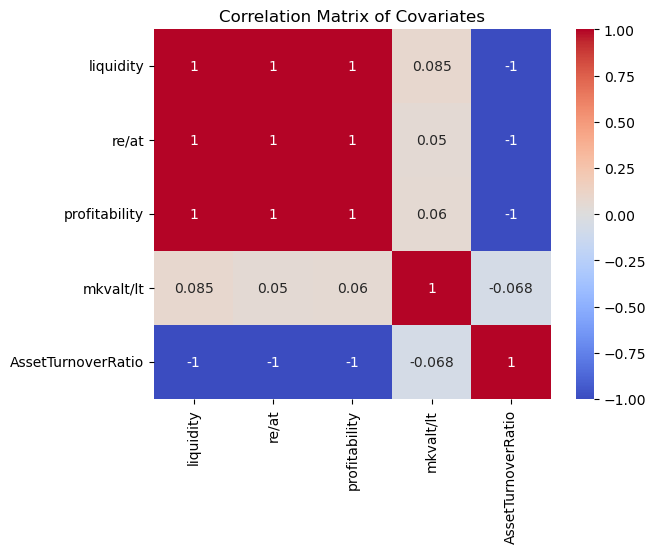

            Covariate       VIF
0           liquidity       inf
1               re/at       inf
2       profitability       inf
3           mkvalt/lt       inf
4  AssetTurnoverRatio       inf
5               const  1.271033
Rank of the matrix: 2


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [159]:
plot_correlation_matrix(df_industrial_data_35[columns_of_ratios])
compute_vif(df_industrial_data_35[columns_of_ratios])
compute_rank(df_industrial_data_35[columns_of_ratios])

In [160]:
df_droping_ratios_35 = df_industrial_data_35.drop(columns=['liquidity','re/at','profitability'])

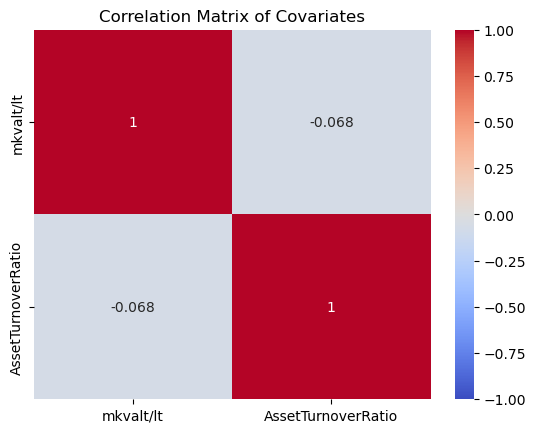

            Covariate       VIF
0           mkvalt/lt  1.004635
1  AssetTurnoverRatio  1.004635
2               const  1.271033
Rank of the matrix: 2


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/3592253628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['const'] = 1


In [161]:
plot_correlation_matrix(df_droping_ratios_35[['mkvalt/lt','AssetTurnoverRatio']])
compute_vif(df_droping_ratios_35[['mkvalt/lt','AssetTurnoverRatio']])
compute_rank(df_droping_ratios_35[['mkvalt/lt','AssetTurnoverRatio']])

In [163]:
cox_proportional_hazard_model(df_droping_ratios_35,['mkvalt/lt','AssetTurnoverRatio'])

Iteration 1: norm_delta = 2.03e+00, step_size = 0.9500, log_lik = -9.92662, newton_decrement = 1.01e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 2.47e+06, step_size = 0.9500, log_lik = -33.14943, newton_decrement = 1.25e+06, seconds_since_start = 0.0


/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['AssetTurnoverRatio'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/fitters/cox_time_varying_fitter.py:526: RuntimeWarning: overflow encountered in exp
  phi_i = weights_at_t * np.exp(np.dot(X_at_t, beta))


ConvergenceError: hessian or gradient contains nan or inf value(s). Convergence halted. Please see the following tips in the lifelines documentation:
https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
array must not contain infs or NaNs

### cox model for copy_industrial_data_35_6

In [165]:
cox_proportional_hazard_model(copy_industrial_data_35_6,columns_of_ratios)

Iteration 1: norm_delta = 5.54e-01, step_size = 0.9500, log_lik = -6.30810, newton_decrement = 1.00e-01, seconds_since_start = 0.0
Iteration 2: norm_delta = 5.21e-01, step_size = 0.9500, log_lik = -6.20266, newton_decrement = 4.40e-02, seconds_since_start = 0.0
Iteration 3: norm_delta = 4.02e-01, step_size = 0.9500, log_lik = -6.14890, newton_decrement = 1.90e-02, seconds_since_start = 0.0
Iteration 4: norm_delta = 3.72e-01, step_size = 1.0000, log_lik = -6.12479, newton_decrement = 1.30e-02, seconds_since_start = 0.0
Iteration 5: norm_delta = 2.22e-01, step_size = 1.0000, log_lik = -6.10837, newton_decrement = 2.64e-03, seconds_since_start = 0.0
Iteration 6: norm_delta = 2.03e-02, step_size = 1.0000, log_lik = -6.10560, newton_decrement = 1.61e-05, seconds_since_start = 0.0
Iteration 7: norm_delta = 1.27e-04, step_size = 1.0000, log_lik = -6.10558, newton_decrement = 7.33e-10, seconds_since_start = 0.0
Convergence completed after 7 iterations.


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = (df['fyear'] - df['ipodate'].dt.year).clip(lower=0)
/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stop_time'] = df['start_time'] + 1  # Each row represents one year


<lifelines.CoxTimeVaryingFitter: fitted with 2615 periods, 684 subjects, 1 events>
         event col = 'bankruptcy'
number of subjects = 684
 number of periods = 2615
  number of events = 1
partial log-likelihood = -6.11
  time fit was run = 2025-03-17 00:25:26 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
liquidity          -0.23      0.80      1.81           -3.78            3.32                0.02               27.79
re/at              -0.06      0.94      0.46           -0.97            0.85                0.38                2.34
profitability       1.52      4.56      4.23           -6.76            9.80                0.00            18018.06
mkvalt/lt          -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
AssetTurnoverRatio -2.10      0.12      5.46          -12.80            8.61                0.00             5467.31

                    cmp to     z    p  -log2(p)
covariate                                      
liquidity             0.00 -0.12 0.90      0.15
re/at                 0.00 -0.13 0.90      0.15
profitability         0.00  0.36 0.72      0.48
mkvalt/lt             0.00 -0.16 0.87      0.20
AssetTurnoverRatio    0.00 -0.38 0.70      0.51
---
Partial AIC = 22.21
log-likelihood ratio test = 0.41 on 5 df
-log2(p) of ll-ratio test = 0.01

### cox model for copy_industrial_data_35

In [166]:
cox_proportional_hazard_model(copy_industrial_data_35,columns_of_ratios)

Iteration 1: norm_delta = 4.62e+00, step_size = 0.9500, log_lik = -9.92662, newton_decrement = 1.00e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 4.23e+04, step_size = 0.9500, log_lik = -18.82443, newton_decrement = 9.72e+03, seconds_since_start = 0.0


/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = (df['fyear'] - df['ipodate'].dt.year).clip(lower=0)
/var/folders/2_/bhldy0qj4k5dfrybcw8kkm6m0000gn/T/ipykernel_9596/2522296403.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stop_time'] = df['start_time'] + 1  # Each row represents one year
/Users/nk/anaconda3/envs/thesisenv1/lib/python3.11/site-packages/lifelines/fitters/cox_time_varying_fitter.py:526:

ConvergenceError: hessian or gradient contains nan or inf value(s). Convergence halted. Please see the following tips in the lifelines documentation:
https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
array must not contain infs or NaNs